In [1]:
# analysis specific imports
import spacenet as sn
import muspan as ms

# general imports
import numpy as np
import matplotlib.pyplot as plt 
from scipy.spatial import cKDTree
import os 

# additional imports
os.chdir('../misc')
from cross_pair_correlation_function import cross_pair_correlation_function
from normalised_cross_correlation import normalised_cross_correlation

np.random.seed(3)  # For reproducibility

# for better res plots
plt.rcParams['figure.dpi'] = 200


# setting parameters for analysis
max_dist = 500
edge_distance = 350
kernel_n = 10
r_step=5
bandwidths = 35

netPCF_kwargs_1 = dict(spatial_kernel_bandwidth=bandwidths,
                        spatial_kernel_n=kernel_n,
                        r_min=0, 
                        r_max=max_dist,
                        r_step=r_step, 
                        return_confidence_interval=True,
                        verbose=True,
                        n_jobs=-1) 


pcf_kwargs_1 = dict(max_R=max_dist,
                annulus_step=r_step,
                annulus_width=bandwidths*2,
                return_confidence_interval=True)




# domain parameters
region_size = (1000, 1000)
muspan_domain_boundary = np.array([[0, 0],
                                    [region_size[0], 0],
                                    [region_size[0], region_size[1]],
                                    [0, region_size[1]]])

# Poisson point pattern parameters
lambda_points = 0.001  # Density of points

# Neyman-Scott cluster process parameters
num_clusters = 8  # Number of clusters
cluster_std_dev = 20  # Standard deviation of cluster points
points_per_cluster = 30  # Number of points per cluster

# background PPP
num_points = int(region_size[0] * region_size[1] * lambda_points)
background_points = np.random.uniform(0, region_size[0], size=(int(np.floor(num_points)), 2))

# matern type 1 parameters
lambda_parent = 0.002  # Density of parent points
hard_core_R = 50  # Minimum distance between points in the Matern Type I process


##### Points PPP ######

# Generate points using a Poisson point process
points = np.random.uniform(0, region_size[0], size=(num_points, 2))

ppp_points = np.vstack((points, background_points))


G_ppp=sn.utils.spatial_network_from_points(ppp_points,network_type='delaunay',max_edge_distance=edge_distance)

objects_indices_ppp = np.arange(len(points))    



# compute netPCF
r1,g1,CI1 = sn.point_patterns.cross_pair_correlation_function(G_ppp,
                                                nodes_a=objects_indices_ppp,
                                                nodes_b=objects_indices_ppp,
                                                **netPCF_kwargs_1)

# compute PCF
ppp_domain = ms.domain('ppp')
ppp_domain.add_points(points,'points')
ppp_domain.estimate_boundary('specify', specify_boundary_coords=muspan_domain_boundary)
ppp_domain.estimate_boundary('alpha shape', alpha_shape_kwargs=dict(alpha=102))

r_pcf1,g_pcf1,CI_pcf1 = cross_pair_correlation_function(ppp_domain,population_A=('collection','points'),population_B=('collection','points'),**pcf_kwargs_1)


##### Matern Type 1 cluster process ######


# take the points from the PPP and run a thinning operation over it 
# Simulation window parameters
area = region_size[0] * region_size[1]
n_parent = np.random.poisson(lambda_parent * area)

parent_points = np.column_stack((
    np.random.uniform(0, region_size[0], n_parent),
    np.random.uniform(0, region_size[1], n_parent)
))


# Step 2: Assign random marks for tie-breaking    
marks = np.random.uniform(0, 1, n_parent)

# Step 2: Build KD-tree for distance queries
tree = cKDTree(parent_points)

# Step 3: Keep only points with no neighbors within R
neighbors = tree.query_ball_point(parent_points, r=hard_core_R)


keep = np.ones(n_parent, dtype=bool)
for i, neigh_list in enumerate(neighbors):
    # Only keep if this point has the minimal mark in its neighborhood
    if any(marks[j] < marks[i] for j in neigh_list if j != i):
        keep[i] = False

    
matern_points = parent_points[keep]
points_mattern_I_all = np.vstack((matern_points, background_points))


G_matern=sn.utils.spatial_network_from_points(points_mattern_I_all,network_type='delaunay',max_edge_distance=edge_distance)
objects_indices_matern = np.arange(len(matern_points))    

# compute netPCF
r1_m,g1_m,CI1_m = sn.point_patterns.cross_pair_correlation_function(G_matern,
                                                      nodes_a=objects_indices_matern,
                                                      nodes_b=objects_indices_matern,
                                                      **netPCF_kwargs_1)

# compute PCF
matern_domain = ms.domain('ppp')
matern_domain.add_points(matern_points,'points')
matern_domain.estimate_boundary('alpha shape', alpha_shape_kwargs=dict(alpha=202))

r_pcf1_m,g_pcf1_m,CI_pcf1_m = cross_pair_correlation_function(matern_domain,population_A=('collection','points'),population_B=('collection','points'),**pcf_kwargs_1)


##### Thomas cluster process ######
cluster_centers = np.random.uniform(0, region_size[0], size=(num_clusters, 2))

# Generate points around each cluster center
clustered_points = []
for center in cluster_centers:
    cluster_points = np.random.normal(loc=center, scale=cluster_std_dev, size=(points_per_cluster, 2))
    clustered_points.append(cluster_points)

# Combine all points into a single array
clustered_points = np.vstack(clustered_points)

# Remove out-of-bounds points
valid_mask = (clustered_points[:, 0] >= 0) & (clustered_points[:, 0] <= region_size[0]) & \
             (clustered_points[:, 1] >= 0) & (clustered_points[:, 1] <= region_size[1])
clustered_points = clustered_points[valid_mask]


clustered_points_all = np.vstack((clustered_points, background_points))

G_thomas=sn.utils.spatial_network_from_points(clustered_points_all,network_type='delaunay',max_edge_distance=edge_distance)

objects_indices_thomas = np.arange(len(clustered_points))    

# compute netPCF
r1_t,g1_t,CI1_t = sn.point_patterns.cross_pair_correlation_function(G_thomas,
                                                      nodes_a=objects_indices_thomas,
                                                      nodes_b=objects_indices_thomas,
                                                      **netPCF_kwargs_1)

# compute PCF
thomas_domain = ms.domain('thomas')
thomas_domain.add_points(clustered_points,'points')
thomas_domain.estimate_boundary('alpha shape', alpha_shape_kwargs=dict(alpha=600))


r_pcf1_t,g_pcf1_t,CI_pcf1_t = cross_pair_correlation_function(thomas_domain,population_A=('collection','points'),population_B=('collection','points'),**pcf_kwargs_1)


##### Strauss cluster process ######


domain_scale = 1
this_region_size = (region_size[0]*domain_scale, region_size[1]*domain_scale)
# Generate a regular lattice of points
def generate_hexagonal_lattice_points(region_size, spacing):
    x_coords = np.arange(0, region_size[0], spacing)
    y_coords = np.arange(0, region_size[1], spacing * np.sqrt(3))
    lattice_points = []

    for x in x_coords:
        for y in y_coords:
            lattice_points.append([x, y])
            if x + spacing / 2 < region_size[0]:  # Add offset for hexagonal structure
                lattice_points.append([x + spacing / 2, y + spacing * np.sqrt(3) / 2])

    return np.array(lattice_points)

spacing = 155  # Adjust the spacing as needed
lattice_points = generate_hexagonal_lattice_points(this_region_size,spacing)

mask = (lattice_points[:, 0] > 0) & (lattice_points[:, 0] < this_region_size[0]) & (lattice_points[:, 1] > 0) & (lattice_points[:, 1] < this_region_size[1])
lattice_points = lattice_points[mask]

lattice_points_all = np.vstack((lattice_points, background_points))


G_strauss=sn.utils.spatial_network_from_points(lattice_points_all,network_type='delaunay',max_edge_distance=edge_distance)
objects_indices_strauss = np.arange(len(lattice_points))    


# compute netPCF
r1_s,g1_s,CI1_s = sn.point_patterns.cross_pair_correlation_function(G_strauss,
                                                      nodes_a=objects_indices_strauss,
                                                      nodes_b=objects_indices_strauss,
                                                      **netPCF_kwargs_1)

# compute PCF
strauss_domain = ms.domain('strauss')
strauss_domain.add_points(lattice_points,'points')
r_pcf1_s,g_pcf1_s,CI_pcf1_s = cross_pair_correlation_function(strauss_domain,population_A=('collection','points'),population_B=('collection','points'),**pcf_kwargs_1)


Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 1000/1000 [00:07<00:00, 132.07contributions/s]


Computing confidence intervals via spatial bootstrap...
Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 139/139 [00:05<00:00, 26.36contributions/s]


Computing confidence intervals via spatial bootstrap...
Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 237/237 [00:05<00:00, 43.64contributions/s] 


Computing confidence intervals via spatial bootstrap...
Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 42/42 [00:04<00:00,  8.84contributions/s]


Computing confidence intervals via spatial bootstrap...


In [3]:
# compute the NCC betweent the euclidean PCF and netPCF
l2_distance_CSR,_ = normalised_cross_correlation(g1,g_pcf1)
l2_distance_mattern,_ = normalised_cross_correlation(g1_m,g_pcf1_m)
l2_distance_strauss,_ = normalised_cross_correlation(g1_s,g_pcf1_s)
l2_distance_thomas,_ = normalised_cross_correlation(g1_t,g_pcf1_t)

Text(115, 2.75, '$NCC(g^{net}(r),g(r))$ = 0.99')

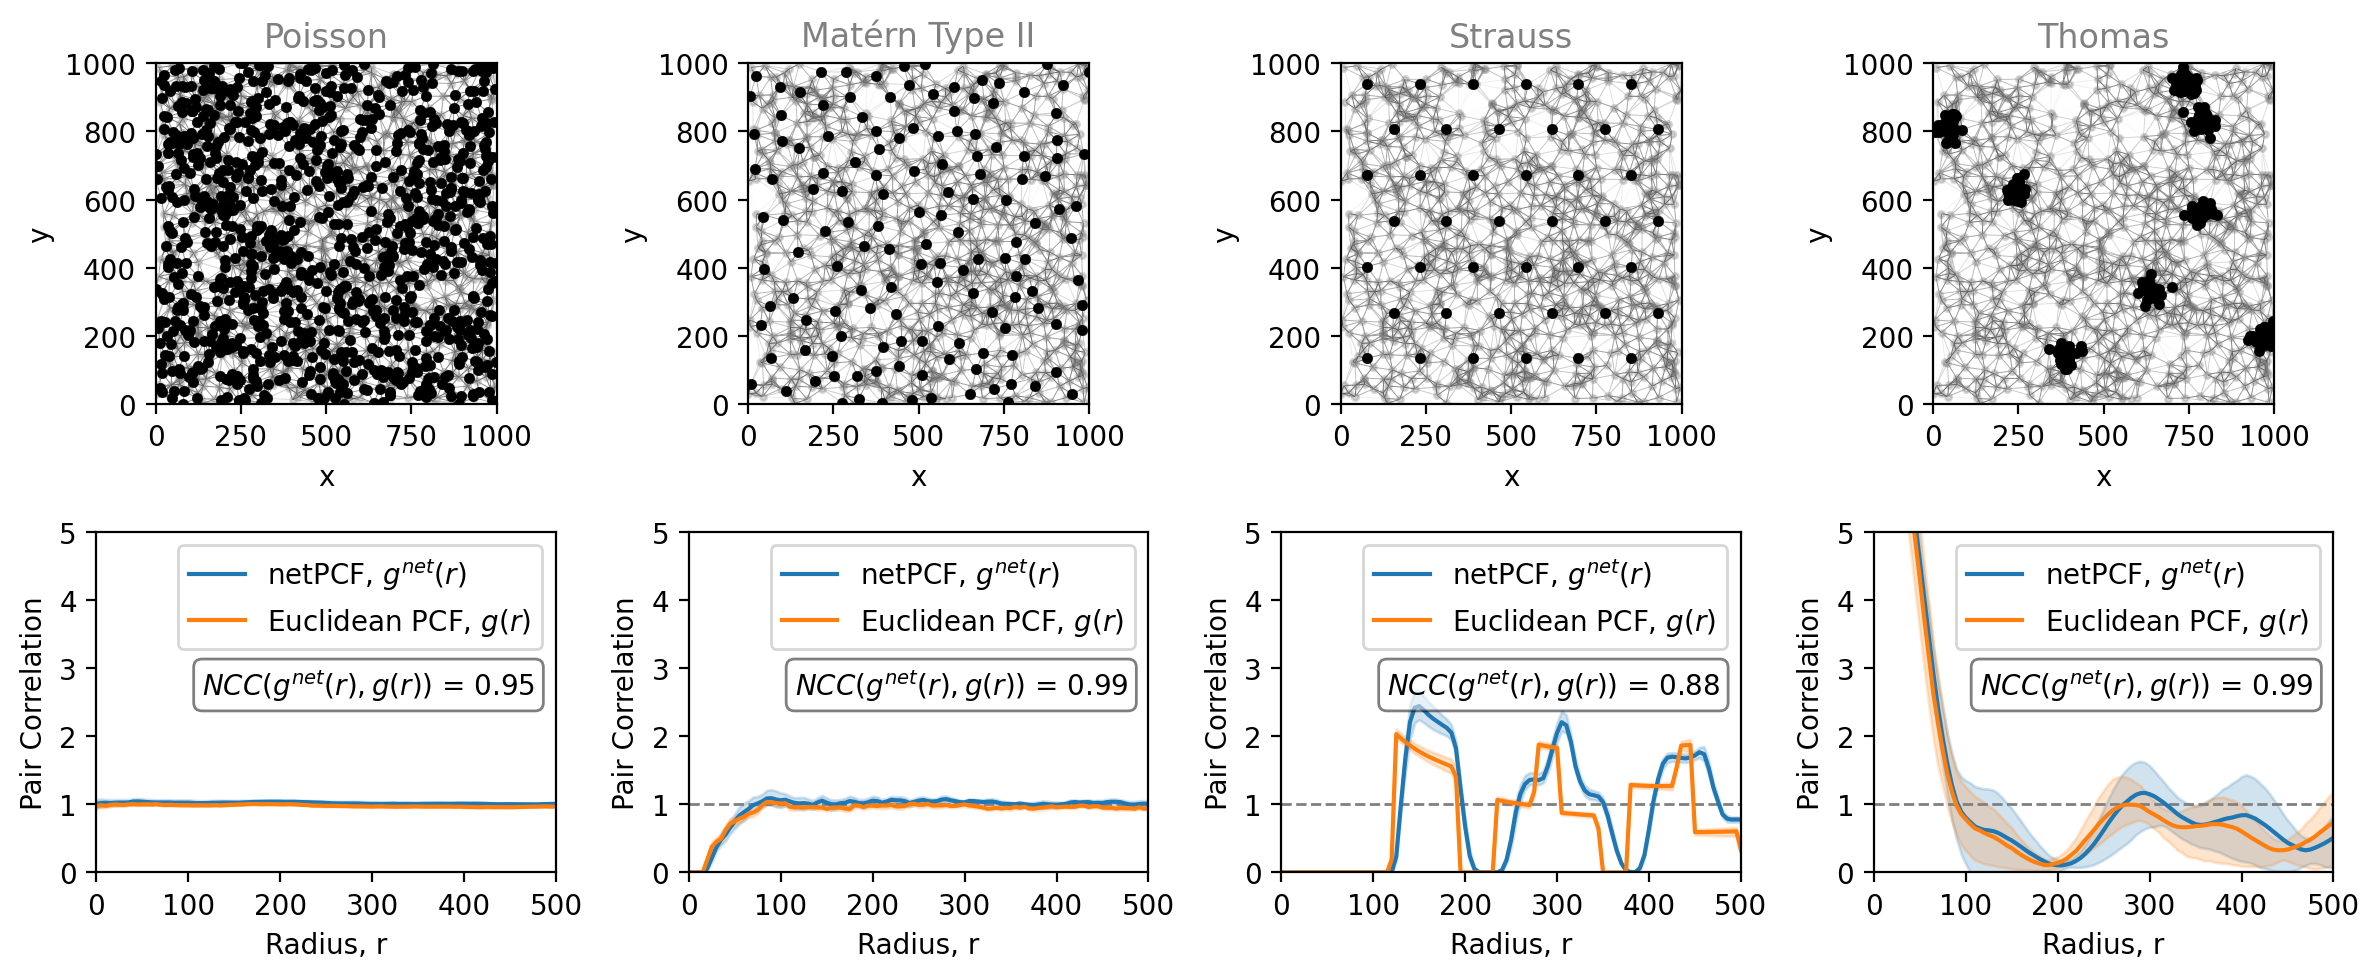

In [4]:

ylim=5
marker_size=15
scatter_kwargs=dict(linewidths=0.1,edgecolors='black')
visualise_paras = dict(edge_width=0.35,marker_size=0,edge_weight_name='Distance',scatter_kwargs=scatter_kwargs,edge_vmax=100) 

fig,ax=plt.subplots(2,4,figsize=(12,5),layout='tight') 

# Plot CSR
sn.utils.plot_spatial_network(G_ppp,ax=ax[0,0],**visualise_paras)
ax[0,0].scatter(background_points[:,0],background_points[:,1],color='tab:grey',s=5,alpha=0.3)
ax[0,0].scatter(points[:,0],points[:,1],color='black',s=marker_size,edgecolors='black',linewidths=0.1)


# Turn on axis spines
ax[0,0].set_axis_on()
ax[0,0].set_xlabel('x')
ax[0,0].set_ylabel('y')
ax[0,0].set_xlim(0, region_size[0]) 
ax[0,0].set_ylim(0, region_size[1]) 
ax[0,0].set_title('Poisson',color='grey')


ax[1,0].axhline(1, color='gray', linestyle='--', linewidth=1)    
ax[1,0].plot(r1,g1,color='tab:blue',label='netPCF, $g^{net}(r)$') 
ax[1,0].fill_between(r1, CI1[0], CI1[1], color='tab:blue', alpha=0.2)

ax[1,0].plot(r_pcf1,g_pcf1,color='tab:orange',label='Euclidean PCF, $g(r)$') 
ax[1,0].fill_between(r_pcf1, CI_pcf1[0], CI_pcf1[1], color='tab:orange', alpha=0.2)

ax[1,0].set_xlabel('Radius, r')
ax[1,0].set_ylabel('Pair Correlation')
ax[1,0].set_xlim(0, max_dist)  
ax[1,0].set_ylim(0, ylim)
ax[1,0].legend()

error_1 = '$NCC(g^{net}(r),g(r))$ = '+ f'{l2_distance_CSR:.2f}'
ax[1,0].text(115,2.75,error_1,va='center',ha='left',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))


# Plot matern 
sn.utils.plot_spatial_network(G_matern,ax=ax[0,1],**visualise_paras)
ax[0,1].scatter(background_points[:,0],background_points[:,1],color='tab:grey',s=5,alpha=0.3)
ax[0,1].scatter(matern_points[:,0],matern_points[:,1],color='black',s=marker_size,edgecolors='black',linewidths=0.1)


ax[0,1].set_axis_on()
ax[0,1].set_xlabel('x')
ax[0,1].set_ylabel('y')
ax[0,1].set_xlim(0, region_size[0]) 
ax[0,1].set_ylim(0, region_size[1]) 
ax[0,1].set_title('Matérn Type II',color='grey')


# plot results
ax[1,1].axhline(1, color='gray', linestyle='--', linewidth=1)    
ax[1,1].plot(r1_m,g1_m,color='tab:blue',label='netPCF, $g^{net}(r)$') 
ax[1,1].fill_between(r1_m, CI1_m[0], CI1_m[1], color='tab:blue', alpha=0.2)

ax[1,1].plot(r_pcf1_m,g_pcf1_m,color='tab:orange',label='Euclidean PCF, $g(r)$') 
ax[1,1].fill_between(r_pcf1_m, CI_pcf1_m[0], CI_pcf1_m[1], color='tab:orange', alpha=0.2)

ax[1,1].set_xlabel('Radius, r')
ax[1,1].set_ylabel('Pair Correlation')
ax[1,1].set_xlim(0, max_dist)  
ax[1,1].set_ylim(0, ylim)
ax[1,1].legend()

error_2 ='$NCC(g^{net}(r),g(r))$ = '+ f'{l2_distance_mattern:.2f}'
ax[1,1].text(115,2.75,error_2,va='center',ha='left',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))


# Plot strauss
sn.utils.plot_spatial_network(G_strauss,ax=ax[0,2],**visualise_paras)
ax[0,2].scatter(background_points[:,0],background_points[:,1],color='tab:grey',s=5,alpha=0.3)
ax[0,2].scatter(lattice_points[:,0],lattice_points[:,1],color='black',s=marker_size,edgecolors='black',linewidths=0.1)

ax[0,2].set_axis_on()
ax[0,2].set_xlabel('x')
ax[0,2].set_ylabel('y')
ax[0,2].set_xlim(0, this_region_size[0]) 
ax[0,2].set_ylim(0, this_region_size[1]) 
ax[0,2].set_title('Strauss',color='grey')


# plot results
ax[1,2].axhline(1, color='gray', linestyle='--', linewidth=1)    
ax[1,2].plot(r1_s,g1_s,color='tab:blue',label='netPCF, $g^{net}(r)$') 
ax[1,2].fill_between(r1_s, CI1_s[0], CI1_s[1], color='tab:blue', alpha=0.2)
ax[1,2].plot(r_pcf1_s,g_pcf1_s,color='tab:orange',label='Euclidean PCF, $g(r)$') 
ax[1,2].fill_between(r_pcf1_s, CI_pcf1_s[0], CI_pcf1_s[1], color='tab:orange', alpha=0.2)

ax[1,2].set_xlabel('Radius, r')
ax[1,2].set_ylabel('Pair Correlation')
ax[1,2].set_xlim(0, max_dist)  
ax[1,2].set_ylim(0, ylim)
ax[1,2].legend()

error_3 = '$NCC(g^{net}(r),g(r))$ = ' f'{l2_distance_strauss:.2f}'
ax[1,2].text(115,2.75,error_3,va='center',ha='left',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))


# thomas plots
sn.utils.plot_spatial_network(G_thomas,ax=ax[0,3],**visualise_paras)
ax[0,3].scatter(background_points[:,0],background_points[:,1],color='tab:grey',s=5,alpha=0.3)
ax[0,3].scatter(clustered_points[:,0],clustered_points[:,1],color='black',s=marker_size,edgecolors='black',linewidths=0.1)

ax[0,3].set_axis_on()
ax[0,3].set_xlabel('x')
ax[0,3].set_ylabel('y')
ax[0,3].set_xlim(0, region_size[0]) 
ax[0,3].set_ylim(0, region_size[1]) 
ax[0,3].set_title('Thomas',color='grey')

# plot results
ax[1,3].axhline(1, color='gray', linestyle='--', linewidth=1)    
ax[1,3].plot(r1_t,g1_t,color='tab:blue',label='netPCF, $g^{net}(r)$') 
ax[1,3].fill_between(r1_t, CI1_t[0], CI1_t[1], color='tab:blue', alpha=0.2)

ax[1,3].plot(r_pcf1_t,g_pcf1_t,color='tab:orange',label='Euclidean PCF, $g(r)$') 
ax[1,3].fill_between(r_pcf1_t, CI_pcf1_t[0], CI_pcf1_t[1], color='tab:orange', alpha=0.2)

ax[1,3].set_xlabel('Radius, r')
ax[1,3].set_ylabel('Pair Correlation')
ax[1,3].set_xlim(0, max_dist)  
ax[1,3].set_ylim(0, ylim)
ax[1,3].legend()

error_4 = '$NCC(g^{net}(r),g(r))$ = ' f'{l2_distance_thomas:.2f}'
ax[1,3].text(115,2.75,error_4,va='center',ha='left',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/figures/recover_classical_w_quant.png',dpi=300,bbox_inches='tight') 
#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/figures/recover_classical_w_quant.pdf',dpi=300,bbox_inches='tight')
